## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)

print('Ready')

Ready


## 2. Load Data

In [4]:
df = pd.read_csv('sensor9.csv', parse_dates=['date'])
df.rename(columns={'9': 'y', 'date': 'ds'}, inplace=True)
df = df.sort_values('ds').reset_index(drop=True)
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df.dropna(subset=['y'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape: {df.shape}  |  {df["ds"].min().date()} -> {df["ds"].max().date()}')

Shape: (1250, 6)  |  2017-05-07 -> 2020-10-07


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ds          1250 non-null   datetime64[us]
 1   y           1250 non-null   float64       
 2   temp        1250 non-null   float64       
 3   wind_speed  1250 non-null   float64       
 4   humidity    1250 non-null   float64       
 5   pressure    1250 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 58.7 KB


## 3. Feature Engineering (Daily Level)

In [6]:
df

,ds,y,temp,wind_speed,humidity,pressure
0,2017-05-07,17.0,13.9,15.8,72.46,914.74
1,2017-05-08,17.0,16.4,10.8,60.54,913.49
2,2017-05-09,17.0,17.9,15.3,52.08,912.98
3,2017-05-10,17.0,19.1,9.0,48.75,911.27
4,2017-05-11,17.0,17.9,23.2,54.42,915.86
...,...,...,...,...,...,...
1245,2020-10-03,25.0,12.5,8.0,46.75,916.87
1246,2020-10-04,21.0,13.0,5.9,38.79,917.59
1247,2020-10-05,18.0,13.1,11.2,32.88,915.87
1248,2020-10-06,18.0,6.2,14.8,59.92,920.29


In [7]:
train_df = df[(df['ds'] >= '2017-07-19') & (df['ds'] < '2020-08-01')].reset_index(drop=True)
test_df = df[(df['ds'] >= '2020-08-01') & (df['ds'] < '2020-09-01')].reset_index(drop=True)

'''def build_features(df):
    d = df.copy()
    
    for lag in [1, 2, 3, 7, 14,30]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    
    y_past = d['y'].shift(1)
    
    d['ewm_7'] = y_past.ewm(span=7).mean()
    d['ewm_3'] = y_past.ewm(span=3).mean()
    
    d['rolling_7'] = y_past.rolling(7).mean()
    d['rolling_3'] = y_past.rolling(3).mean()
    d['rolling_14'] = y_past.rolling(14).mean()
    
    d['month'] = d['ds'].dt.month
    d['dayofyear'] = d['ds'].dt.dayofyear

    d['month_sin'] = np.sin(2 * np.pi * d['month']/12)
    d['month_cos'] = np.cos(2 * np.pi * d['month']/12)


    d['tem_lag_1'] = d['temp'].shift(1)
    
    return d'''


def build_features(df):

    d = df[['ds', 'y']].copy()
    for lag in [1, 2, 3, 7, 14,30]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    y_past = d['y'].shift(1)

    d['ewm_7'] = y_past.ewm(span=7).mean()
    d['ewm_3'] = y_past.ewm(span=3).mean()
    d['ewm_14'] = y_past.ewm(span=14).mean()
    d['ewm_30'] = y_past.ewm(span=30).mean()
   
    d['rolling_7'] = y_past.rolling(7).mean()
    d['rolling_14'] = y_past.rolling(14).mean()
    d['rolling_30'] = y_past.rolling(30).mean()

    d['month'] = d['ds'].dt.month
    d['dayofweek'] = d['ds'].dt.dayofweek
    d['dayofyear'] = d['ds'].dt.dayofyear

    return d


df_with_features = build_features(df)
df_with_features.dropna(inplace=True)

feat_train = df_with_features[(df_with_features['ds'] >= '2017-04-22') & 
                              (df_with_features['ds'] < '2019-06-01')]

feat_test = df_with_features[(df_with_features['ds'] >= '2019-06-01') & 
                             (df_with_features['ds'] < '2019-7-01')]

print(f'Train shape: {feat_train.shape}')
print(f'Test shape: {feat_test.shape}')

Train shape: (725, 18)
Test shape: (30, 18)


In [8]:
df_with_features.columns

Index(['ds', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
       'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14',
       'rolling_30', 'month', 'dayofweek', 'dayofyear'],
      dtype='str')

In [9]:
df_with_features.isna().sum().sum()

0

## 4. Metrics Helper

In [10]:
def get_metrics(y_true, y_pred):
    yt = np.array(y_true, dtype=float)
    yp = np.array(y_pred, dtype=float)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100

    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}

print('Metrics function ready')

Metrics function ready


## 5. Define Feature Columns

In [11]:
'''FEATURE_COLS = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
                'ewm_7', 'ewm_14', 'rolling_7', 'rolling_14', 'rolling_30','ewm_3', 'ewm_30', 'rolling_3','diff_1', 'velocity', 'rolling_std_7', 'month_sin', 
                'month_cos', 'day_sin', 'day_cos', 'expanding_mean',
                'month', 'dayofweek', 'dayofyear']'''

FEATURE_COLS = [ 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
       'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14',
       'rolling_30', 'month', 'dayofweek', 'dayofyear']
print(f'Features: {len(FEATURE_COLS)} columns')
print(f'  {FEATURE_COLS}')

Features: 16 columns
  ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14', 'rolling_30', 'month', 'dayofweek', 'dayofyear']


## 6. Best 30-Day Window Search — Lowest MAPE

Scanned 1101 windows of 30 days each.

Top 10 windows with lowest MAPE:
------------------------------------------------------------------------
  2018-08-31 → 2018-09-29  [    ]  train= 451d  MAPE= 11.41% ◄ BEST
  2018-08-26 → 2018-09-24  [    ]  train= 446d  MAPE= 11.94%
  2018-08-25 → 2018-09-23  [    ]  train= 445d  MAPE= 12.07%
  2018-08-28 → 2018-09-26  [    ]  train= 448d  MAPE= 12.21%
  2018-08-27 → 2018-09-25  [    ]  train= 447d  MAPE= 12.47%
  2018-09-01 → 2018-09-30  [    ]  train= 452d  MAPE= 12.58%
  2018-08-24 → 2018-09-22  [    ]  train= 444d  MAPE= 12.62%
  2018-08-30 → 2018-09-28  [    ]  train= 450d  MAPE= 12.84%
  2018-09-06 → 2018-10-05  [    ]  train= 457d  MAPE= 12.89%
  2018-09-04 → 2018-10-03  [    ]  train= 455d  MAPE= 13.01%
------------------------------------------------------------------------

✓ Best window: 2018-08-31 → 2018-09-29  (MAPE = 11.41%)


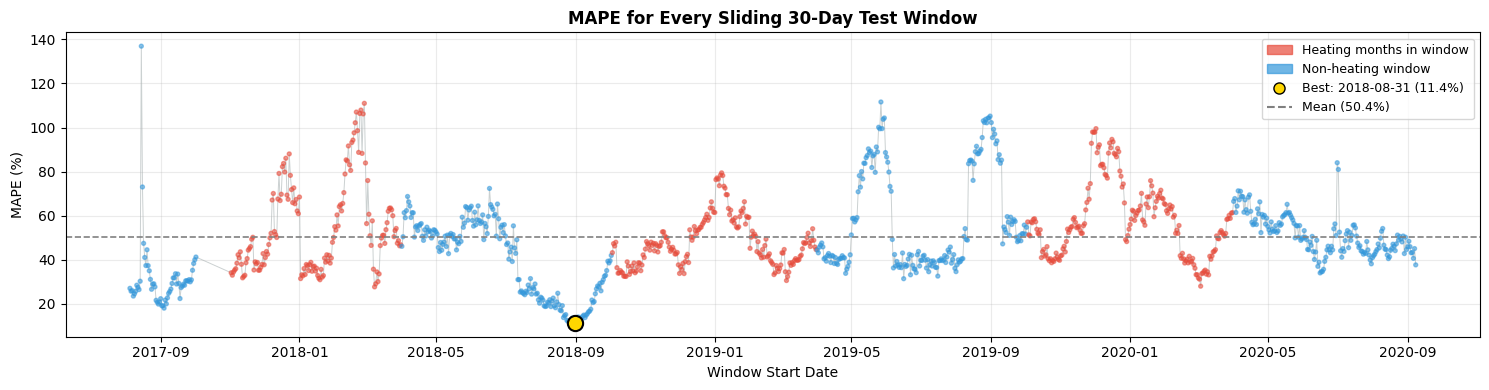


feat_train : 2017-06-06 → 2018-08-30  (451 days)
feat_test  : 2018-08-31 → 2018-09-29  (30 days)

→ All models below will train/test on this optimal 30-day window.


In [12]:
# ── Sliding 30-day window scan: find the best test window (any start date) ──
# Tries every possible 30-day test window across the full dataset.
# For each window: all data BEFORE it = training set.
# Uses fast GradientBoosting. Requires at least 60 days of training data.
# Also respects the heating-season rule from the random forest notebook.

from sklearn.ensemble import GradientBoostingRegressor as _GBR
from sklearn.metrics import mean_absolute_percentage_error as _mape_fn

_HEAT     = {11, 12, 1, 2, 3}
_WINDOW   = 30        # test window size in days
_MIN_TRAIN = 60       # minimum training days required

_gb_scan = _GBR(n_estimators=150, learning_rate=0.08,
                max_depth=4, random_state=42)

# Work from df_with_features (already has features + dropna applied)
_fdf = df_with_features.reset_index(drop=True)
_dates = pd.to_datetime(_fdf['ds'].values)
_n = len(_fdf)

_scan_rows = []

for _start_i in range(_MIN_TRAIN, _n - _WINDOW + 1):
    _end_i = _start_i + _WINDOW          # exclusive

    _te_mask = (_fdf.index >= _start_i) & (_fdf.index < _end_i)
    _tr_mask = _fdf.index < _start_i

    _tr = _fdf[_tr_mask]
    _te = _fdf[_te_mask]

    if len(_te) < _WINDOW:               # guard: need full 30-day window
        continue

    # Heating season check for the test window
    _te_months = set(_te['ds'].dt.month)
    _te_is_heat = bool(_te_months & _HEAT)

    # If test window is heating, require heating in training too
    _tr_months = set(_tr['ds'].dt.month)
    if _te_is_heat and not (_tr_months & _HEAT):
        continue

    _gb_scan.fit(_tr[FEATURE_COLS].values, _tr['y'].values)
    _pred = np.clip(_gb_scan.predict(_te[FEATURE_COLS].values), 0, None)
    _mape = _mape_fn(_te['y'].values, _pred) * 100

    _scan_rows.append({
        'start_date'  : _dates[_start_i],
        'end_date'    : _dates[_end_i - 1],
        'start_i'     : _start_i,
        'n_train_days': len(_tr),
        'is_heating'  : _te_is_heat,
        'MAPE(%)'     : round(_mape, 2),
    })

_scan_df  = pd.DataFrame(_scan_rows)
_best_idx = _scan_df['MAPE(%)'].idxmin()
_best_row = _scan_df.loc[_best_idx]

# ── Print top-10 windows ───────────────────────────────────────────────────
print(f"Scanned {len(_scan_df)} windows of {_WINDOW} days each.")
print(f"\nTop 10 windows with lowest MAPE:")
print("-" * 72)
_top10 = _scan_df.nsmallest(10, 'MAPE(%)')
for _, row in _top10.iterrows():
    marker = " ◄ BEST" if row['start_i'] == _best_row['start_i'] else ""
    season = "HEAT" if row['is_heating'] else "    "
    print(f"  {row['start_date'].date()} → {row['end_date'].date()}  "
          f"[{season}]  train={row['n_train_days']:4d}d  "
          f"MAPE={row['MAPE(%)']:6.2f}%{marker}")
print("-" * 72)
print(f"\n✓ Best window: {_best_row['start_date'].date()} → "
      f"{_best_row['end_date'].date()}  "
      f"(MAPE = {_best_row['MAPE(%)']:.2f}%)")

# ── Plot: all windows MAPE over time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
_colors_line = ['#E74C3C' if h else '#3498DB' for h in _scan_df['is_heating']]
ax.scatter(_scan_df['start_date'], _scan_df['MAPE(%)'],
           c=_colors_line, s=8, alpha=0.55, zorder=2)
ax.plot(_scan_df['start_date'], _scan_df['MAPE(%)'],
        color='#7F8C8D', lw=0.7, alpha=0.4, zorder=1)
ax.axhline(_scan_df['MAPE(%)'].mean(), color='grey', ls='--', lw=1.2,
           label=f"Mean MAPE ({_scan_df['MAPE(%)'].mean():.1f}%)")
# Mark best point
ax.scatter([_best_row['start_date']], [_best_row['MAPE(%)']],
           color='gold', s=120, edgecolors='black', lw=1.5,
           zorder=5, label=f"Best: {_best_row['start_date'].date()} "
                           f"({_best_row['MAPE(%)']:.1f}%)")
import matplotlib.patches as _mp
ax.legend(handles=[
    _mp.Patch(color='#E74C3C', alpha=0.7, label='Heating months in window'),
    _mp.Patch(color='#3498DB', alpha=0.7, label='Non-heating window'),
    plt.Line2D([0],[0], marker='o', color='gold', markeredgecolor='black',
               markersize=8, lw=0, label=f"Best: {_best_row['start_date'].date()} "
                                         f"({_best_row['MAPE(%)']:.1f}%)"),
    plt.Line2D([0],[0], color='grey', ls='--',
               label=f"Mean ({_scan_df['MAPE(%)'].mean():.1f}%)"),
], fontsize=9, loc='upper right')
ax.set_title(f"MAPE for Every Sliding {_WINDOW}-Day Test Window",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Window Start Date"); ax.set_ylabel("MAPE (%)")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

# ── Set feat_train / feat_test to the best window ─────────────────────────
_best_start_i = int(_best_row['start_i'])
_best_end_i   = _best_start_i + _WINDOW

feat_train = _fdf.iloc[:_best_start_i].copy()
feat_test  = _fdf.iloc[_best_start_i:_best_end_i].copy()

feat_train = feat_train.set_index('ds')
feat_test  = feat_test.set_index('ds')

print(f"\nfeat_train : {feat_train.index.min().date()} → "
      f"{feat_train.index.max().date()}  ({len(feat_train)} days)")
print(f"feat_test  : {feat_test.index.min().date()} → "
      f"{feat_test.index.max().date()}  ({len(feat_test)} days)")
print("\n→ All models below will train/test on this optimal 30-day window.")


## 7. Train / Test Arrays from Best Window

In [13]:
X_train = feat_train[FEATURE_COLS].values
y_train = feat_train['y'].values

X_test = feat_test[FEATURE_COLS].values
y_test = feat_test['y'].values

## 7.1 Gradient boostimg method 

In [14]:
'''from sklearn.ensemble import GradientBoostingRegressor

GB_PARAMS = dict(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    min_samples_split = 5,
    min_samples_leaf  = 3,
    max_features      = 'sqrt',
    loss              = 'huber',
    random_state      = 42,
)

MODEL_NAME  = 'GradientBoosting'
MODEL_COLOR = '#9B59B6'

fold_results = []
fold_preds = []
lgb_imps = []


print(f'{MODEL_NAME} (Daily-level testing)')

model = GradientBoostingRegressor(**GB_PARAMS)

model.fit(X_train, y_train)

pred = np.clip(model.predict(X_test), 0, None)
m = get_metrics(y_test, pred)

print(m)

print(f'\nTraining complete!')'''

"from sklearn.ensemble import GradientBoostingRegressor\n\nGB_PARAMS = dict(\n    n_estimators      = 300,\n    learning_rate     = 0.05,\n    max_depth         = 4,\n    subsample         = 0.8,\n    min_samples_split = 5,\n    min_samples_leaf  = 3,\n    max_features      = 'sqrt',\n    loss              = 'huber',\n    random_state      = 42,\n)\n\nMODEL_NAME  = 'GradientBoosting'\nMODEL_COLOR = '#9B59B6'\n\nfold_results = []\nfold_preds = []\nlgb_imps = []\n\n\nprint(f'{MODEL_NAME} (Daily-level testing)')\n\nmodel = GradientBoostingRegressor(**GB_PARAMS)\n\nmodel.fit(X_train, y_train)\n\npred = np.clip(model.predict(X_test), 0, None)\nm = get_metrics(y_test, pred)\n\nprint(m)\n\nprint(f'\nTraining complete!')"

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

MODEL_NAME  = 'GradientBoosting'
GD_MODEL_COLOR = '#9B59B6'

param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10],
    'loss': ['squared_error', 'huber']
}


random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, 
    cv=5, 
    random_state=42,
    scoring='neg_mean_absolute_error', 
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Use the best model found
gb = random_search.best_estimator_
print(f"Best Params: {random_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'subsample': 0.6, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'loss': 'huber', 'learning_rate': 0.1}


In [16]:
pred = np.clip(gb.predict(X_test), 0, None)
m = get_metrics(y_test, pred)

print(m)

print(f'\nTraining complete!')

{'MAE': 2.457780008251181, 'RMSE': 3.294972206728589, 'MAPE(%)': 9.984130143700478, 'R2': -0.276399550478754}

Training complete!


## 7.2 Prediction Plots

In [17]:
train_set = feat_train
test_set=feat_test

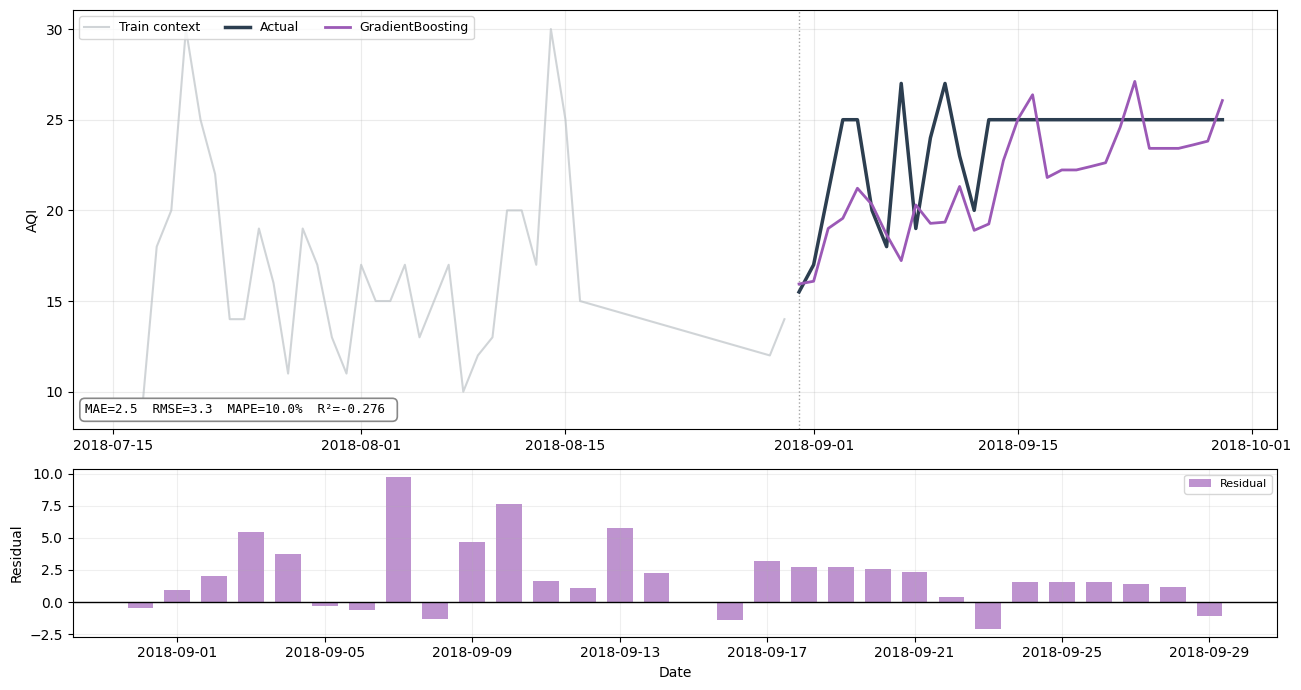

In [18]:
# Show first 3 folds in detail

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                        gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
ax.plot(tr_dates[ctx], y_train[ctx],
        color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

te_dates = pd.to_datetime(test_set.index)
ax.plot(te_dates, y_test,
        color='#2C3E50', lw=2.5, label='Actual', zorder=5)


ax.plot(te_dates, pred,
        color=GD_MODEL_COLOR, lw=2, label=MODEL_NAME, zorder=6)

ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('AQI')


ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(alpha=0.25)

txt = (f"MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  "
        f"MAPE={m['MAPE(%)']:.1f}%  R²={m['R2']:.3f} ")
ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
        fontsize=9, va='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

ax2 = axes[1]
ax2.bar(te_dates, y_test - pred,
        color=GD_MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 7.3 Feature Importace  

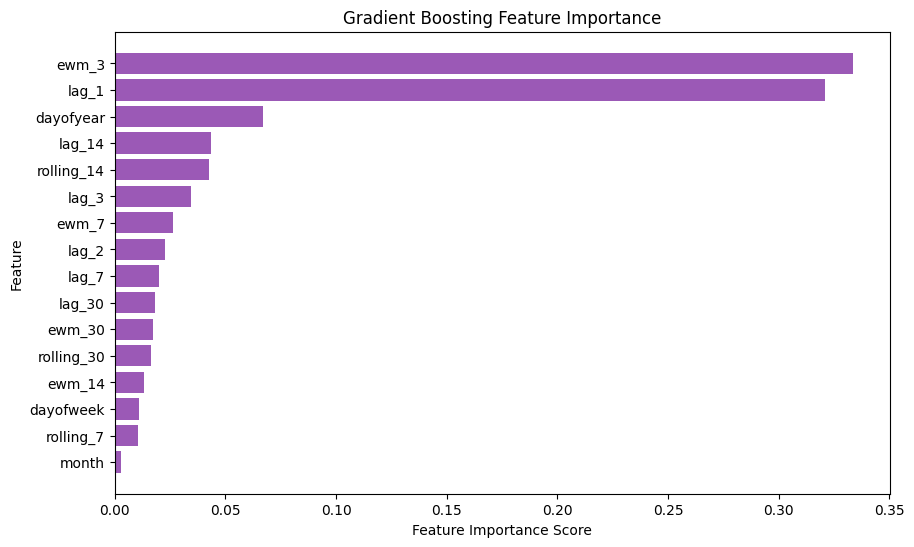

In [19]:
importances = gb.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
})


feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance_df)), feature_importance_df['importance'], align='center', color = GD_MODEL_COLOR)
plt.yticks(np.arange(len(feature_importance_df)), feature_importance_df['feature'])
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.title('Gradient Boosting Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

# 8.1 CatBoost


In [20]:
from catboost import CatBoostRegressor

param_dist = {
    'iterations': [1000, 2000, 3000],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 2],
    'random_strength': [1, 2, 5]
}
CAT_MODEL_NAME  = 'CatBoost'
CAT_MODEL_COLOR = '#E67E22'

base_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=0
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=15,           # Number of random combinations to try
    cv=3,                # 3-fold cross-validation
    scoring='neg_root_mean_squared_error',
    random_state=42,     # Seed for the selection process
    n_jobs=-1
)


random_search.fit(X_train, y_train)

cat = random_search.best_estimator_

print(f"Best CatBoost Params: {random_search.best_params_}")

Best CatBoost Params: {'random_strength': 1, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 2000, 'depth': 8, 'bagging_temperature': 0}


In [21]:
print(f'{CAT_MODEL_NAME} (Daily-level testing)')
cat.fit(X_train, y_train, verbose=False)

cat_pred = np.clip(cat.predict(X_test), 0, None)
met_cat = get_metrics(y_test, cat_pred)

print(met_cat)

print(f'\nTraining complete!')

CatBoost (Daily-level testing)
{'MAE': 3.3359295243607816, 'RMSE': 4.0537487493500395, 'MAPE(%)': 13.827896246563157, 'R2': -0.9319540224775562}

Training complete!


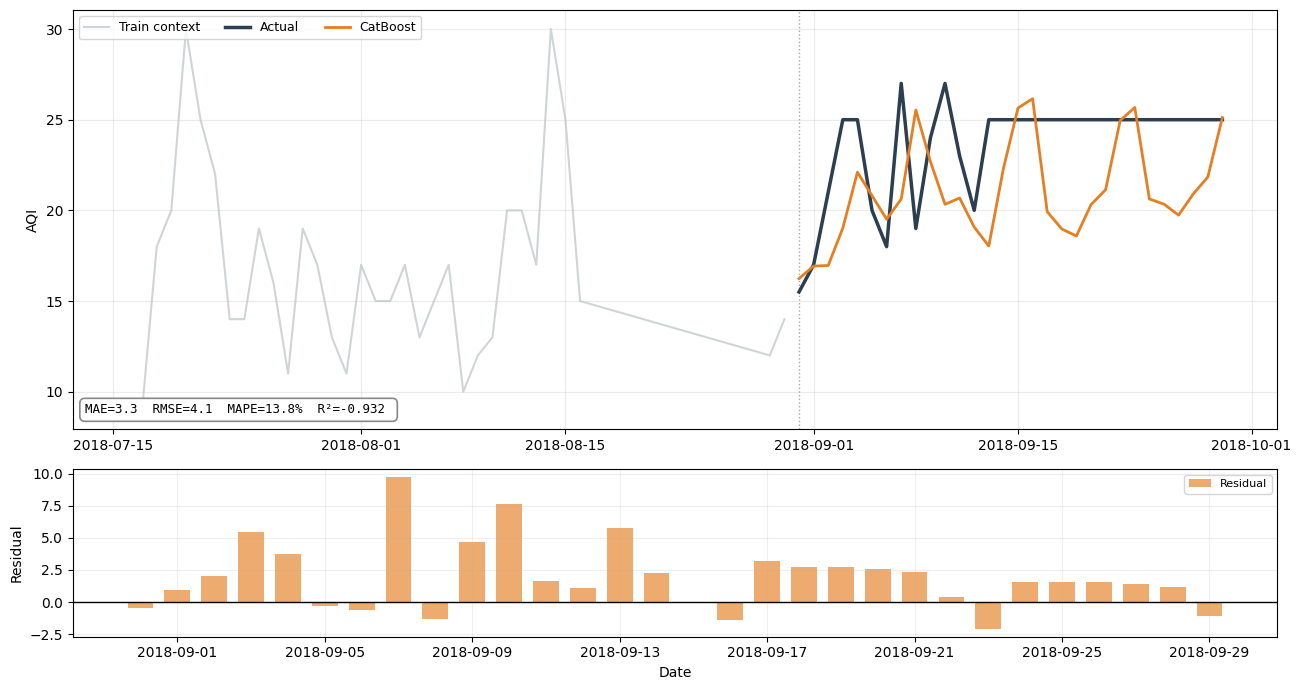

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                        gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
ax.plot(tr_dates[ctx], y_train[ctx],
        color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

te_dates = pd.to_datetime(test_set.index)
ax.plot(te_dates, y_test,
        color='#2C3E50', lw=2.5, label='Actual', zorder=5)


ax.plot(te_dates, cat_pred,
        color=CAT_MODEL_COLOR, lw=2, label=CAT_MODEL_NAME, zorder=6)

ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('AQI')


ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(alpha=0.25)

txt = (f"MAE={met_cat['MAE']:.1f}  RMSE={met_cat['RMSE']:.1f}  "
        f"MAPE={met_cat['MAPE(%)']:.1f}%  R²={met_cat['R2']:.3f} ")
ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
        fontsize=9, va='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

ax2 = axes[1]
ax2.bar(te_dates, y_test - pred,
        color=CAT_MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

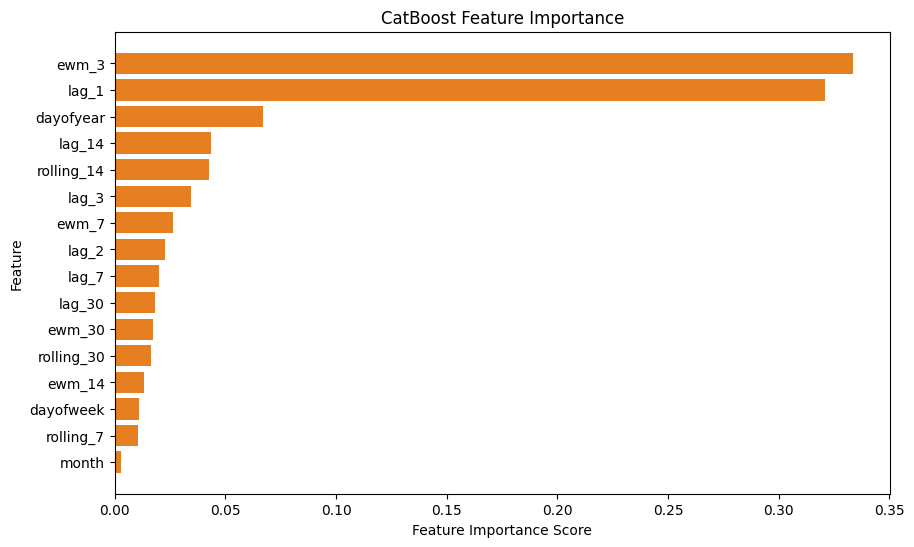

In [23]:
importances = gb.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
})


feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance_df)), feature_importance_df['importance'], align='center', color = CAT_MODEL_COLOR)
plt.yticks(np.arange(len(feature_importance_df)), feature_importance_df['feature'])
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

# 9.1 XGBosst


In [24]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

param_dist = {
    'n_estimators': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [1.0, 1.5, 2.0]
}

XG_MODEL_NAME  = 'XGBoost'
XG_MODEL_COLOR = '#3498DB'


# Remove early_stopping_rounds from here
xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='rmse'
)


random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10, 
    cv=3, 
    random_state=42, 
    scoring='neg_root_mean_squared_error'
)


random_search.fit(
    X_train, y_train
)

xgb_b = random_search.best_estimator_
print(f"Best XGBoost Params: {random_search.best_params_}")



Best XGBoost Params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [25]:
print(f'{XG_MODEL_NAME} (Daily-level testing)')

# Pass the eval_set so early stopping has data to look at
xgb_b.fit(
    X_train, 
    y_train, 
    verbose=False # Set to True if you want to see the RMSE drop each round
)

# Also fixed: make sure you use 'xgb_b' to predict, not 'cat'
xgb_b_pred = np.clip(xgb_b.predict(X_test), 0, None)
met_xgb_b = get_metrics(y_test, xgb_b_pred)

print(met_xgb_b)
print(f'\nTraining complete!')

XGBoost (Daily-level testing)
{'MAE': 2.5524145126342774, 'RMSE': 3.1807029934570963, 'MAPE(%)': 10.400848101748625, 'R2': -0.18940392271032835}

Training complete!


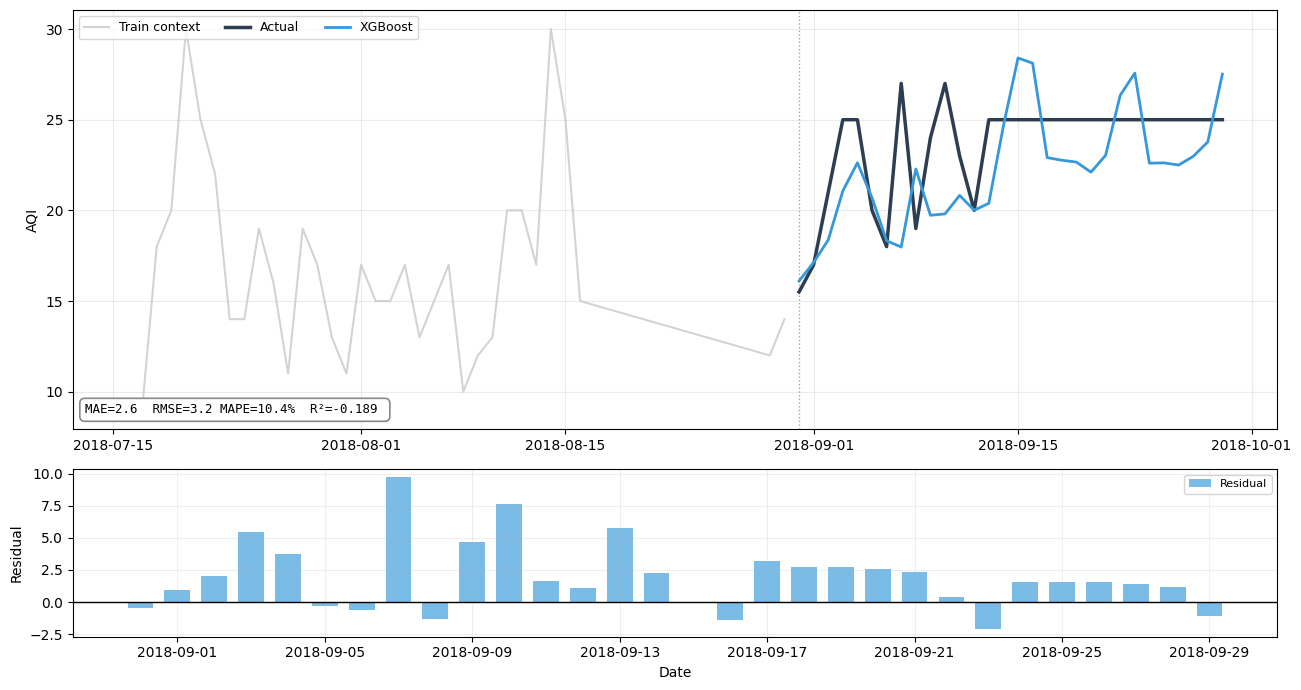

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                        gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
ax.plot(tr_dates[ctx], y_train[ctx],
        color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

te_dates = pd.to_datetime(test_set.index)
ax.plot(te_dates, y_test,
        color='#2C3E50', lw=2.5, label='Actual', zorder=5)


ax.plot(te_dates, xgb_b_pred,
        color=XG_MODEL_COLOR, lw=2, label=XG_MODEL_NAME, zorder=6)

ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('AQI')


ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(alpha=0.25)

txt = (f"MAE={met_xgb_b['MAE']:.1f}  RMSE={met_xgb_b['RMSE']:.1f} "
        f"MAPE={met_xgb_b['MAPE(%)']:.1f}%  R²={met_xgb_b['R2']:.3f} ")

ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
        fontsize=9, va='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

ax2 = axes[1]
ax2.bar(te_dates, y_test - pred,
        color=XG_MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

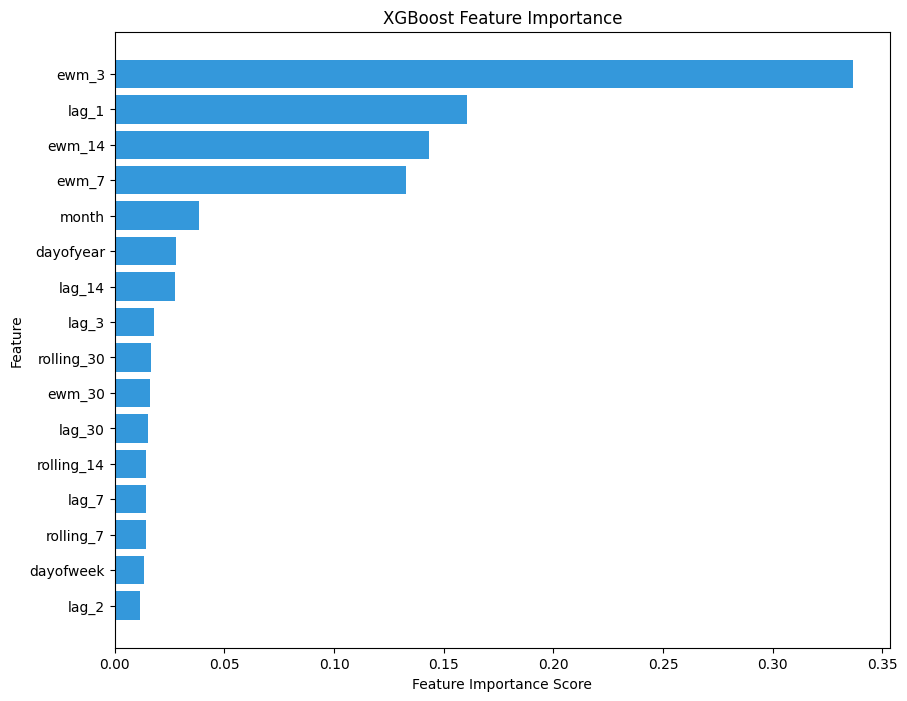

In [27]:
importances_xg = xgb_b.feature_importances_

# 2. Create DataFrame (FIXED: 'feature' should come from your X columns)
feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS, 
    'importance': importances_xg
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], 
         feature_importance_df['importance'], 
         color=XG_MODEL_COLOR) # Use XGB color here

plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.title(f'{XG_MODEL_NAME} Feature Importance') # Changed title to XGBoost
plt.gca().invert_yaxis() 
plt.show()

# 10.1 MLP

In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the MLP Search Space
param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)], # Layers and neurons
    'activation': ['relu', 'tanh'],                              # Activation functions
    'solver': ['adam', 'sgd'],                                   # Optimization algorithms
    'alpha': [0.0001, 0.001, 0.01],                             # L2 penalty (regularization)
    'learning_rate_init': [0.001, 0.01],                         # Initial learning rate
    'max_iter': [1000]                                           # Ensure enough iterations to converge
}

MLP_MODEL_NAME = 'MLP_NeuralNet'
MLP_MODEL_COLOR = "#45C47A" 


mlp_base = MLPRegressor(
    random_state=42,
    early_stopping=True,   
    validation_fraction=0.1, 
    n_iter_no_change=10   
)


random_search_mlp = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=param_dist_mlp,
    n_iter=10, 
    cv=3, 
    random_state=42, 
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)


random_search_mlp.fit(X_train, y_train)

mlp_b = random_search_mlp.best_estimator_
print(f"Best MLP Params: {random_search_mlp.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best MLP Params: {'solver': 'adam', 'max_iter': 1000, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (50, 50), 'alpha': 0.01, 'activation': 'relu'}


In [29]:
mlp_pred = np.clip(mlp_b.predict(X_test), 0, None)
mlp_met = get_metrics(y_test, mlp_pred)
print(f"MLP Results: {mlp_met}")

MLP Results: {'MAE': 2.3656993526997327, 'RMSE': 3.687371798819684, 'MAPE(%)': 9.865014658110045, 'R2': -0.5985160124695657}


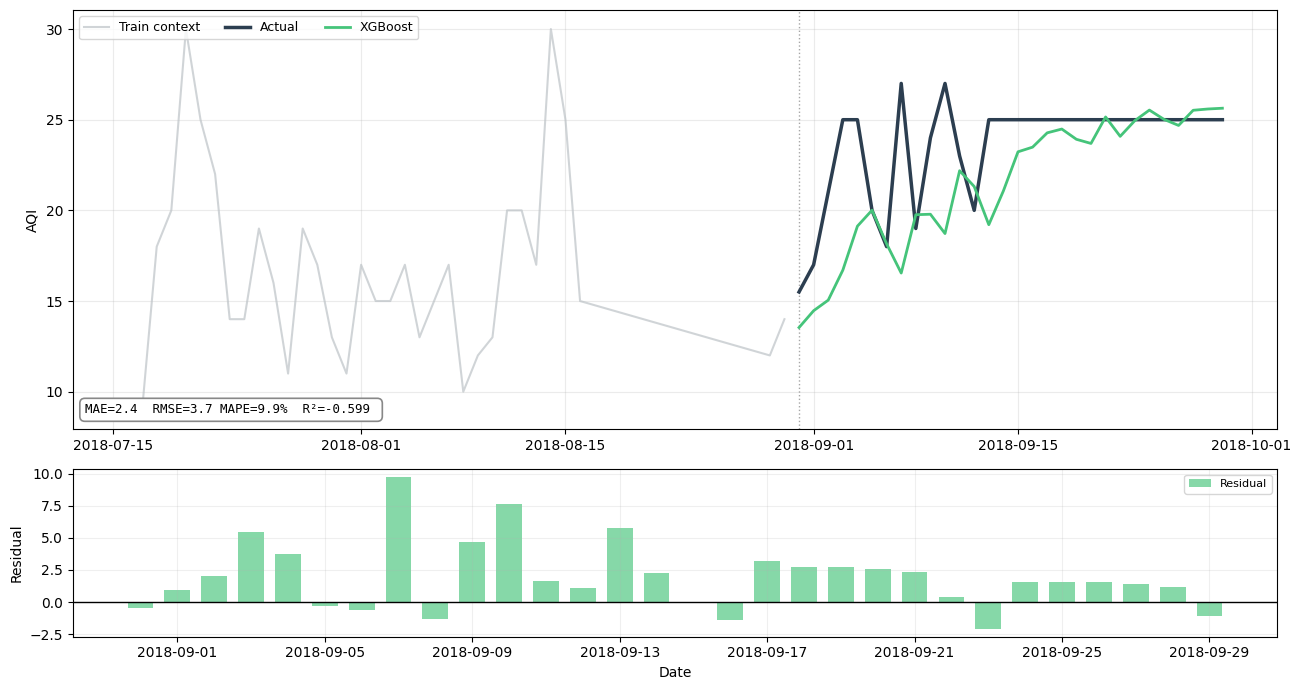

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                        gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
ax.plot(tr_dates[ctx], y_train[ctx],
        color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

te_dates = pd.to_datetime(test_set.index)
ax.plot(te_dates, y_test,
        color='#2C3E50', lw=2.5, label='Actual', zorder=5)


ax.plot(te_dates, mlp_pred,
        color=MLP_MODEL_COLOR, lw=2, label=XG_MODEL_NAME, zorder=6)

ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('AQI')


ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(alpha=0.25)

txt = (f"MAE={mlp_met['MAE']:.1f}  RMSE={mlp_met['RMSE']:.1f} "
        f"MAPE={mlp_met['MAPE(%)']:.1f}%  R²={mlp_met['R2']:.3f} ")

ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
        fontsize=9, va='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

ax2 = axes[1]
ax2.bar(te_dates, y_test - pred,
        color=MLP_MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

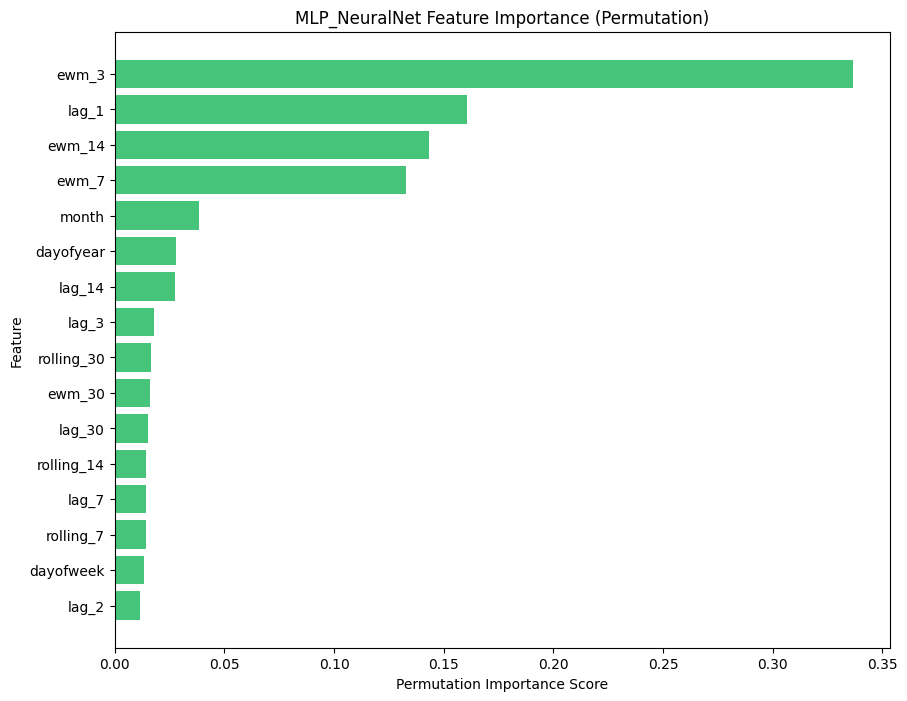

In [31]:
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], 
         feature_importance_df['importance'], 
         color=MLP_MODEL_COLOR)

plt.xlabel('Permutation Importance Score')
plt.ylabel('Feature')
plt.title(f'{MLP_MODEL_NAME} Feature Importance (Permutation)')
plt.gca().invert_yaxis() 
plt.show()

# 10.2 RandomForestRegressor

In [32]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

RF_MODEL_NAME = 'RandomForest'
RF_MODEL_COLOR = "#AE2754" 
RF_PARAMS = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
# Initialize the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Setup the Search
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=RF_PARAMS,
    n_iter=10, 
    cv=3, 
    random_state=42, 
    scoring='neg_root_mean_squared_error',
    verbose=1
)

# Fit the search
print(f'Training {RF_MODEL_NAME}...')
random_search_rf.fit(X_train, y_train)

# Get the winner
rf_b = random_search_rf.best_estimator_
print(f"Best RF Params: {random_search_rf.best_params_}")

Training RandomForest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}


In [33]:

rf_pred = np.clip(rf_b.predict(X_test), 0, None)

met_rf = get_metrics(y_test, rf_pred)

print(f'\n{RF_MODEL_NAME} Results:')
print(met_rf)


RandomForest Results:
{'MAE': 2.344482291179621, 'RMSE': 3.1943663976638486, 'MAPE(%)': 9.60548694193731, 'R2': -0.1996445595207894}


In [34]:
def plotting(MODEL_COLOR_, MODEL_NAME_, y_pred, metrics):

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                            gridspec_kw={'height_ratios': [2.5, 1]})

    ax = axes[0]
    tr_dates = pd.to_datetime(train_set.index)
    ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
    ax.plot(tr_dates[ctx], y_train[ctx],
            color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

    te_dates = pd.to_datetime(test_set.index)
    ax.plot(te_dates, y_test,
            color='#2C3E50', lw=2.5, label='Actual', zorder=5)


    ax.plot(te_dates, y_pred,
            color=MODEL_COLOR_, lw=2, label=MODEL_NAME_, zorder=6)

    ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
    ax.set_ylabel('AQI')


    ax.legend(fontsize=9, ncol=3, loc='upper left')
    ax.grid(alpha=0.25)

    txt = (f"MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f} "
            f"MAPE={metrics['MAPE(%)']:.1f}%  R²={metrics['R2']:.3f} ")

    ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
            fontsize=9, va='bottom', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

    ax2 = axes[1]
    ax2.bar(te_dates, y_test - y_pred,
            color=MODEL_COLOR_, alpha=0.65, label='Residual', width=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

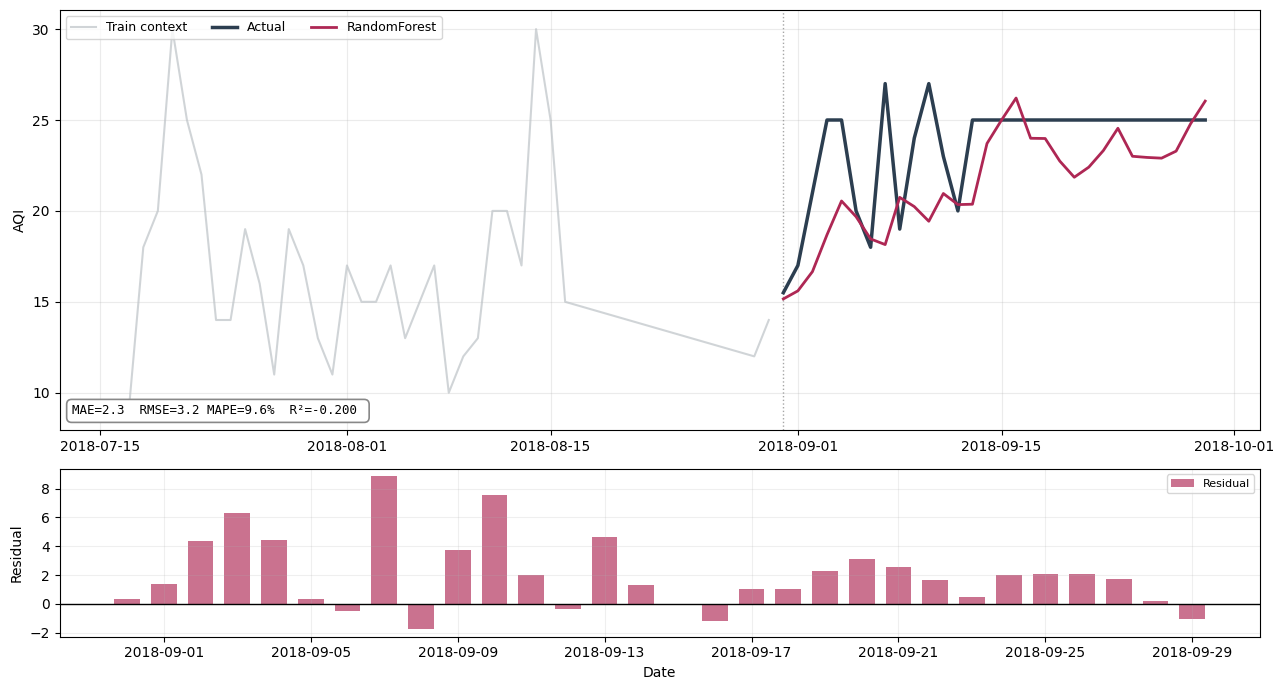

In [35]:
plotting(RF_MODEL_COLOR, RF_MODEL_NAME, rf_pred, met_rf)

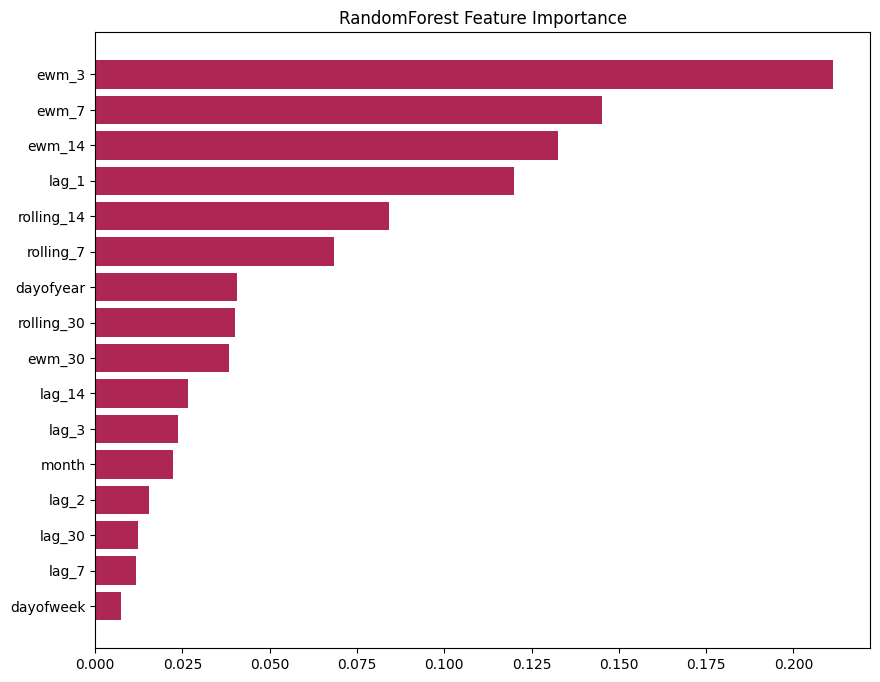

In [36]:
importances_rf = rf_b.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS, 
    'importance': importances_rf
}).sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], 
         feature_importance_df['importance'], 
         color=RF_MODEL_COLOR)
plt.title(f'{RF_MODEL_NAME} Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [37]:
import tensorflow as tf
import numpy as np
import random
import os

def set_all_seeds(seed=42):
    # 1. Set Python core random seed
    random.seed(seed)
    
    # 2. Set Python environment seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Set NumPy seed
    np.random.seed(seed)
    
    # 4. Set TensorFlow seed
    tf.random.set_seed(seed)
    
    # 5. Force TensorFlow to use deterministic operations (Optional)
    # Note: This can slightly slow down training
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Call the function
set_all_seeds(42)

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

DL_MODEL_NAME = 'Deep_Learning_Keras'
DL_MODEL_COLOR = "#DCE73C" 

def build_deep_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2), # Randomly turns off 20% of neurons to prevent overfitting
        #Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1) # Final layer for regression (no activation)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


input_dim = X_train.shape[1]
dl_model = build_deep_model(input_dim)


early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print(f"Training {DL_MODEL_NAME}...")
history = dl_model.fit(
    X_train, y_train,
    #validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


dl_pred = np.clip(dl_model.predict(X_test).flatten(), 0, None)
met_dl = get_metrics(y_test, dl_pred)

print(f'\n{DL_MODEL_NAME} Results:')
print(met_dl)

Training Deep_Learning_Keras...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Deep_Learning_Keras Results:
{'MAE': 3.5836453755696613, 'RMSE': 4.229503311886742, 'MAPE(%)': 14.641568028685311, 'R2': -1.1031094266986479}


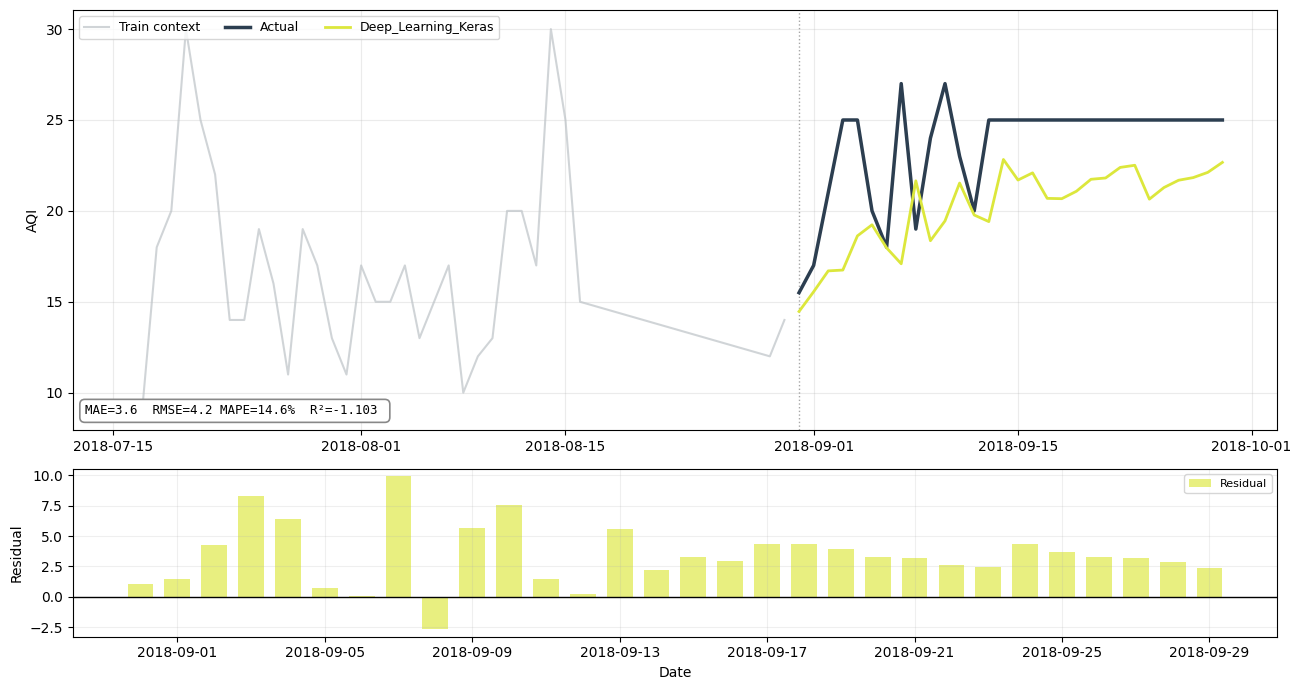

In [39]:
plotting(DL_MODEL_COLOR, DL_MODEL_NAME, dl_pred, met_dl)

In [40]:
import tensorflow as tf
import numpy as np
import random
import os

def set_all_seeds(seed=42):
    # 1. Core Python seed
    random.seed(seed)
    # 2. Environment seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    # 3. NumPy seed (Crucial for data shuffling)
    np.random.seed(seed)
    # 4. TensorFlow seed (Crucial for Weight Initialization)
    tf.random.set_seed(seed)
    # 5. Optional: Force CPU determinism (Slower but more consistent)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_all_seeds(42)

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

GRU_MODEL_NAME = 'GRU_RNN'
GRU_MODEL_COLOR = '#8E44AD' # Deep Purple

X_train_gru = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_gru = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        # return_sequences=False because we only want the final prediction
        GRU(128, activation='relu', return_sequences=False), 
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        #Dense(8, activation='relu'),
        Dense(4, activation='relu'),
        Dense(2, activation='relu'),
        Dense(1) 
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


input_shape = (X_train_gru.shape[1], X_train_gru.shape[2]) 
gru_model = build_gru_model(input_shape)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print(f"Training {GRU_MODEL_NAME}...")
gru_model.fit(
    X_train_gru, y_train,
    #validation_data=(X_test_gru, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


gru_pred = np.clip(gru_model.predict(X_test_gru).flatten(), 0, None)
met_gru = get_metrics(y_test, gru_pred)

print(f'\n{GRU_MODEL_NAME} Results:')
print(met_gru)

Training GRU_RNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step

GRU_RNN Results:
{'MAE': 2.703655974070231, 'RMSE': 3.7666294777682032, 'MAPE(%)': 11.184944242767163, 'R2': -0.6679726802538302}


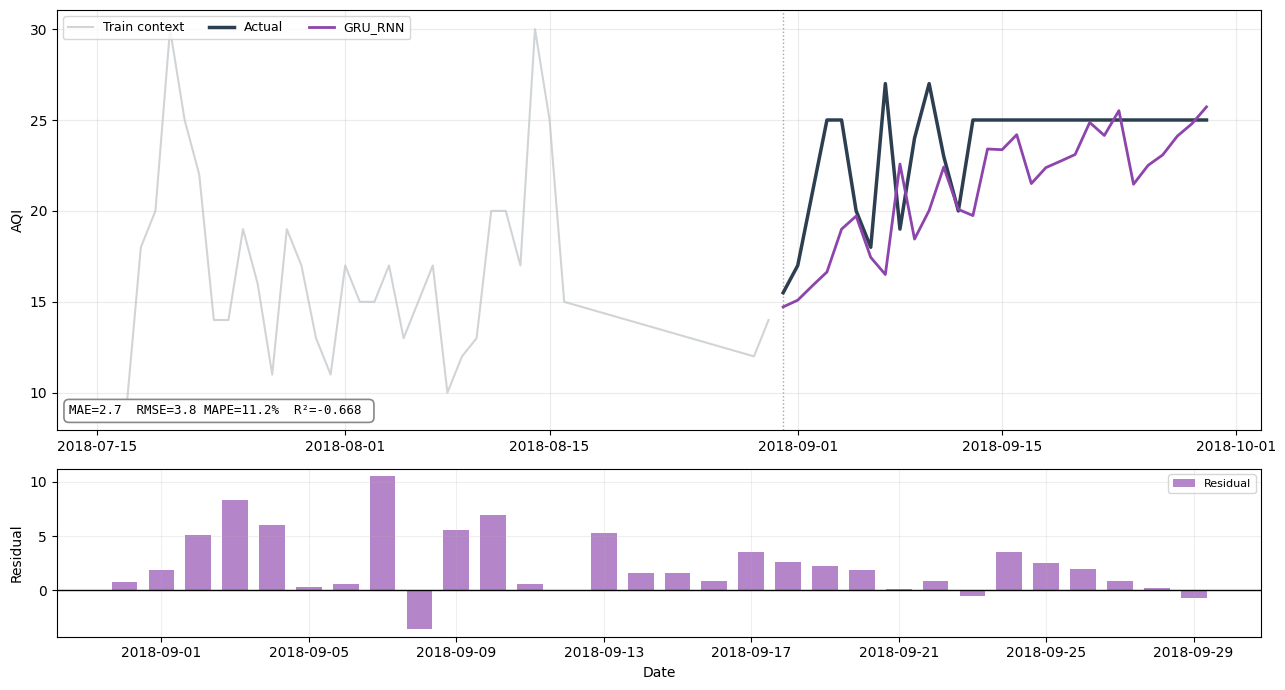

In [42]:
plotting(GRU_MODEL_COLOR, GRU_MODEL_NAME, gru_pred, met_gru)

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

LSTM_MODEL_NAME = 'LSTM_RNN'
LSTM_MODEL_COLOR = "#22C9E6" 


X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(256, activation='relu', return_sequences=False, 
             kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        Dropout(0.2),
        Dense(128, activation='relu'),#128/32/16
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
lstm_model = build_lstm_model(input_shape)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print(f"Training {LSTM_MODEL_NAME}...")
lstm_model.fit(
    X_train_lstm, y_train,
    #validation_data=(X_test_lstm, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predict
lstm_pred = np.clip(lstm_model.predict(X_test_lstm).flatten(), 0, None)
met_lstm = get_metrics(y_test, lstm_pred)

print(f'\n{LSTM_MODEL_NAME} Results:')
print(met_lstm)

Training LSTM_RNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step

LSTM_RNN Results:
{'MAE': 3.7905157089233397, 'RMSE': 4.515622984005814, 'MAPE(%)': 15.590943237652723, 'R2': -1.3972784481647786}


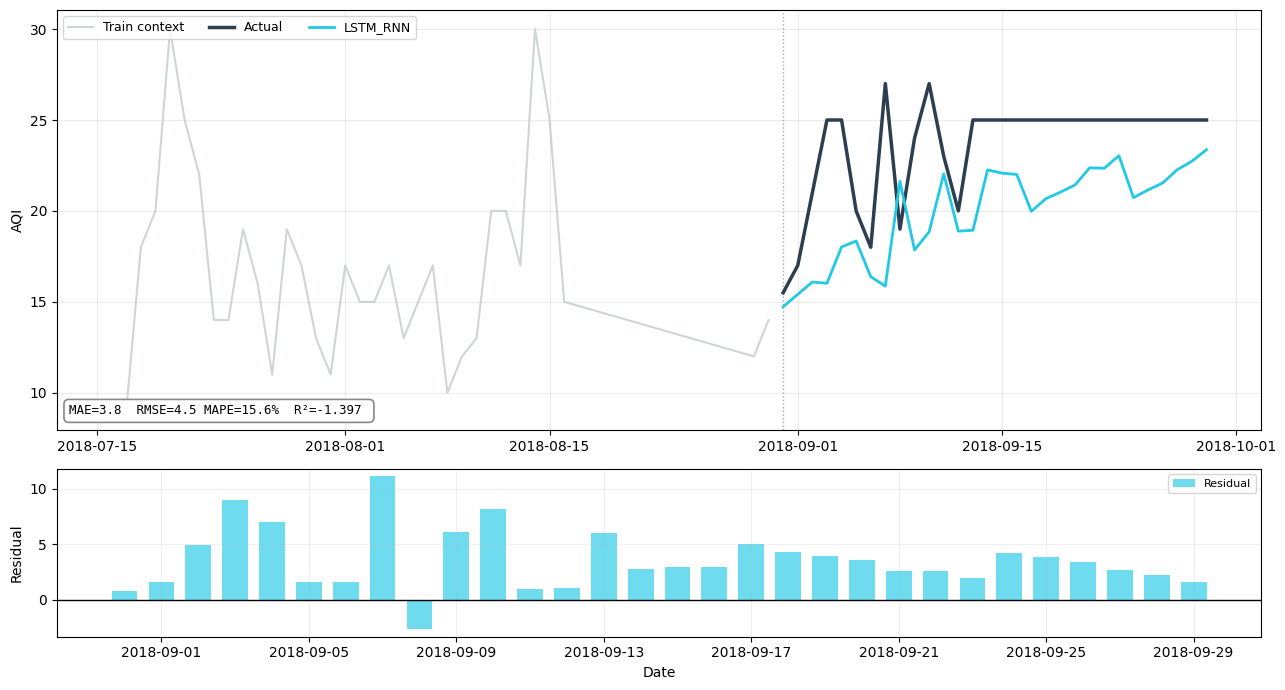

In [44]:
plotting(LSTM_MODEL_COLOR, LSTM_MODEL_NAME, lstm_pred, met_lstm)

In [45]:
predictions = {
    'Gradient Boosting':pred, 
    'CatBoost':cat_pred,
    'XGBoost': xgb_b_pred,
    'MLP':mlp_pred,
    'Random Forest': rf_pred, 
    'DL model': dl_pred,
    'GRU': gru_pred,
    'LSTM':lstm_pred 
}

In [46]:
colors = [GD_MODEL_COLOR, CAT_MODEL_COLOR, XG_MODEL_COLOR, MLP_MODEL_COLOR, RF_MODEL_COLOR, DL_MODEL_COLOR, GRU_MODEL_COLOR, LSTM_MODEL_COLOR]

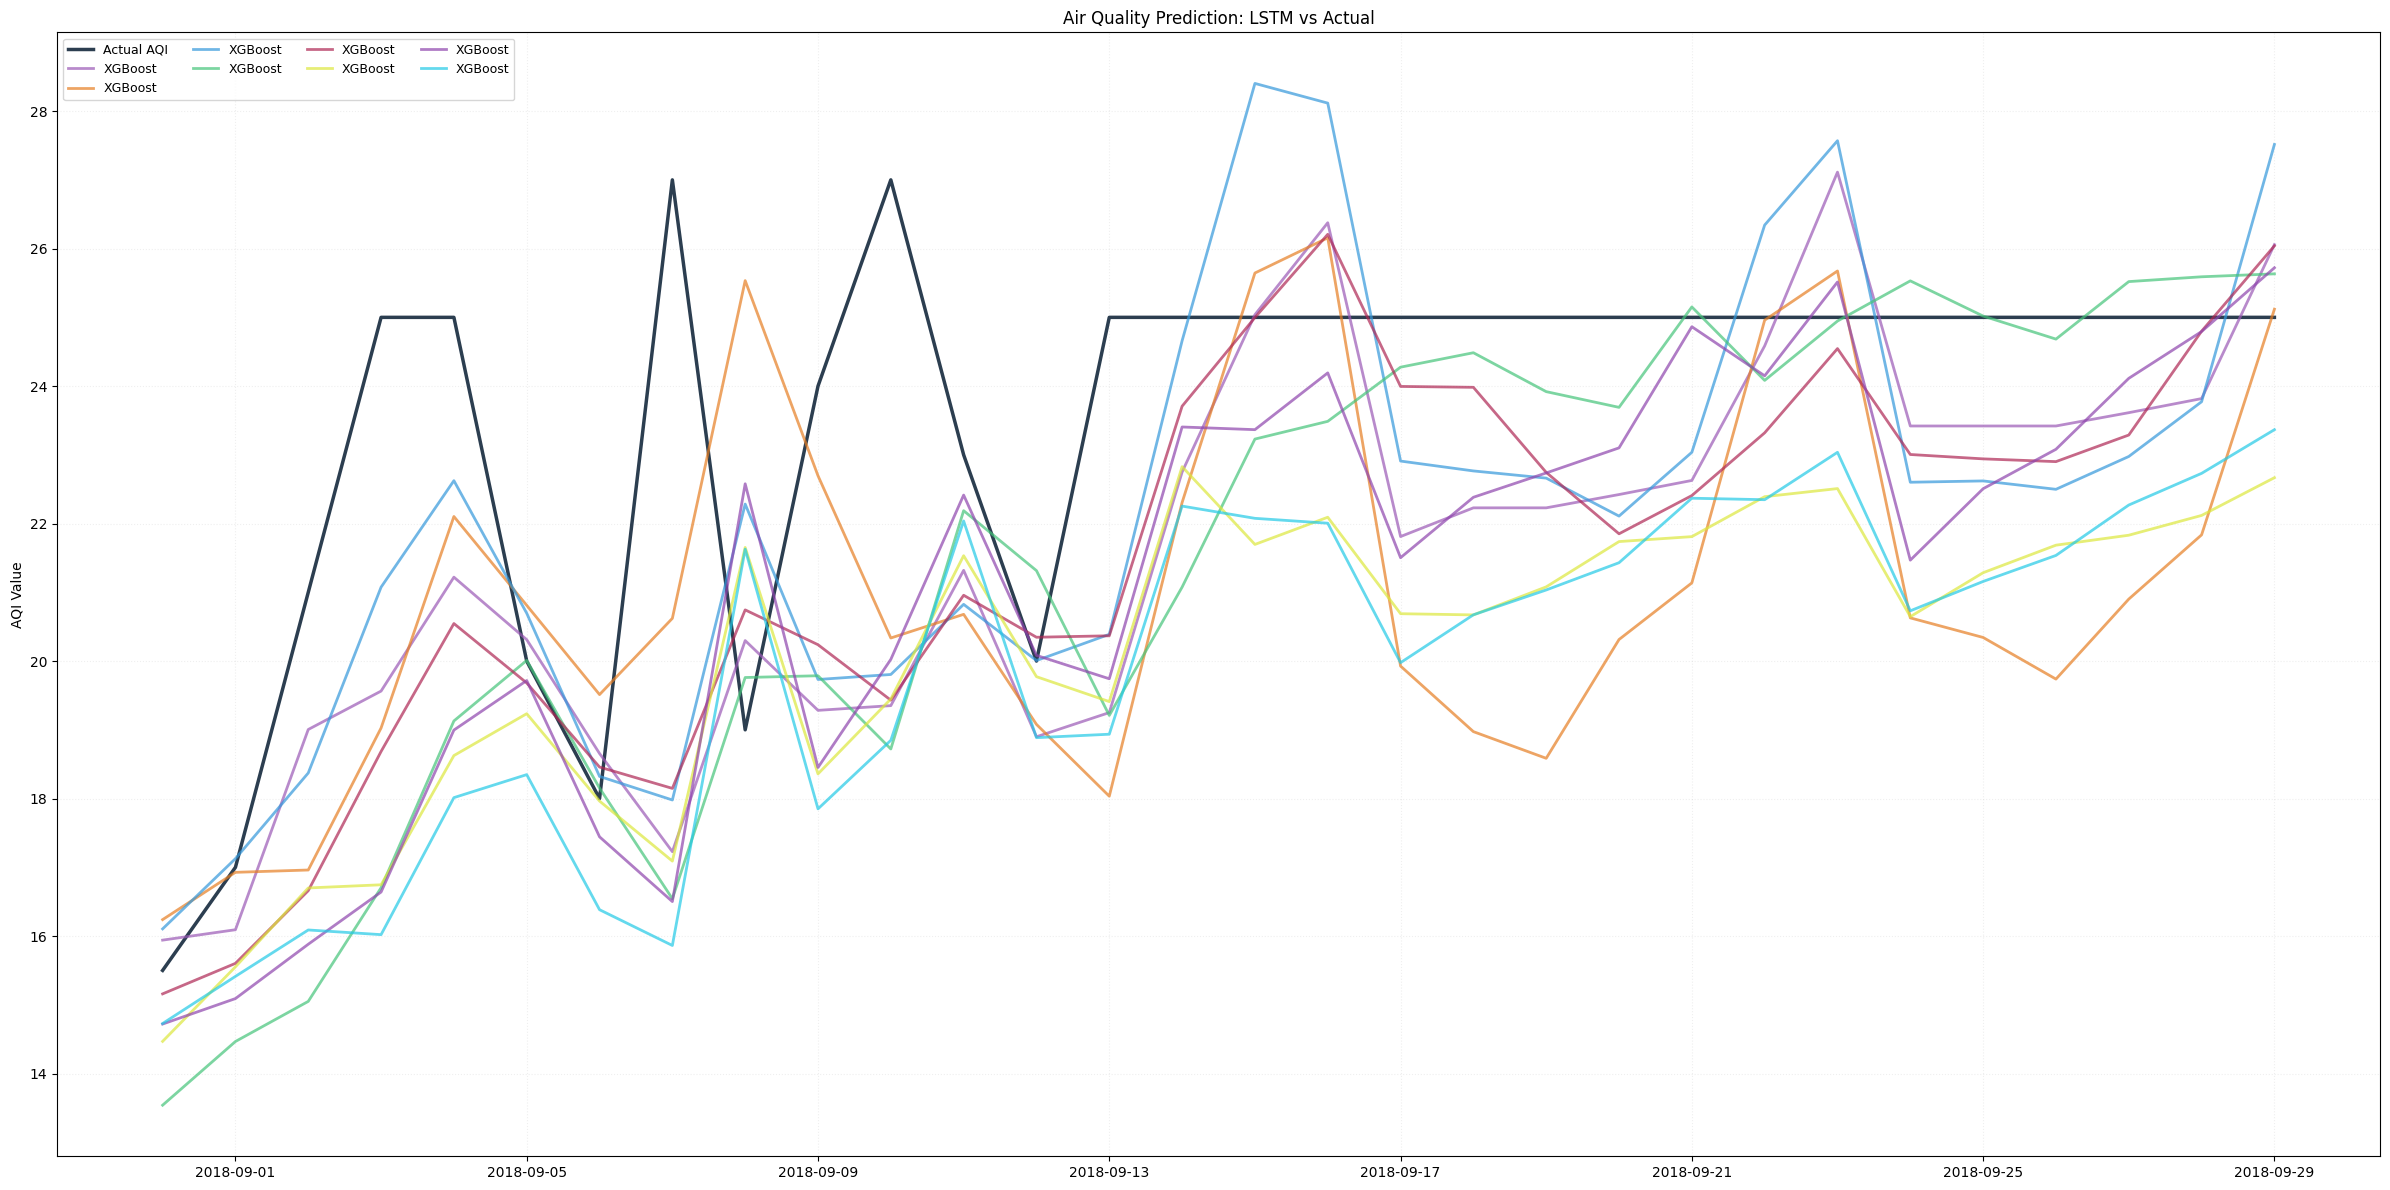

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a single plot
plt.figure(figsize=(24, 12))

# 1. Plot Train context (The last 45 days of training data)
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)


# 2. Plot Actual Test values
te_dates = pd.to_datetime(test_set.index)
plt.plot(te_dates, y_test,
         color='#2C3E50', lw=2.5, label='Actual AQI', zorder=5)


for index, (key, value) in enumerate(predictions.items(), start=0):
    plt.plot(te_dates, value,
            color=colors[index], lw=2, label=XG_MODEL_NAME, zorder=6, alpha=0.7)
    plt.title(f'Air Quality Prediction: {key} vs Actual')

plt.ylabel('AQI Value')
#plt.title(f'Air Quality Prediction: {XG_MODEL_NAME} vs Actual')
plt.legend(fontsize=9, ncol=4, loc='upper left')
plt.grid(alpha=0.2, ls=':')

plt.tight_layout()
plt.show()

In [48]:
df_pred = pd.DataFrame(predictions)
df_pred

,Gradient Boosting,CatBoost,XGBoost,MLP,Random Forest,DL model,GRU,LSTM
0,15.940673,16.239126,16.104174,13.539591,15.158900,14.467858,14.720055,14.727648
1,16.091964,16.926943,17.125969,14.466066,15.602736,15.552070,15.090508,15.413279
2,19.004693,16.960727,18.372305,15.049573,16.659955,16.699636,15.880911,16.088476
3,19.563574,19.026508,21.075079,16.702760,18.685004,16.745771,16.640265,16.020359
4,21.220586,22.103121,22.624254,19.129035,20.545842,18.625303,18.996319,18.013556
5,20.311747,20.810812,20.695827,20.009578,19.681572,19.234514,19.716793,18.348200
6,18.655287,19.512543,18.322136,18.152465,18.458198,17.963638,17.443607,16.383257
7,17.227427,20.621415,17.979408,16.543067,18.148097,17.090477,16.501495,15.862844
8,20.298081,25.534213,22.283583,19.760872,20.744697,21.653046,22.578800,21.627607
9,19.283144,22.695966,19.732151,19.786685,20.237973,18.358755,18.451918,17.850378


In [49]:
df_pred.to_csv('model_predictions_30_days.csv', index=False)
print(f'All the predictions saved as ')

All the predictions saved as 
